# Loading in the data

In [1]:
from tara_preprocessing import make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,full_preprocessing_hold,car
from noah_production_funcs import index_ecog_globally,single_patient_prediction_pure,create_lapaican_rbf
from tara_preprocessing import remove_duplicates,remove_duplicates_2
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import torch
import torch.nn.utils.parametrize as parametrize
import geoopt
from scipy.stats import kurtosis
from scipy import signal
import pandas as pd
from scipy.io import loadmat
from tara_preprocessing import make_patient_correlation_matrix
from noah_production_funcs import create_u

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
cleaned,xyz_clean = remove_duplicates_2(ecogs,xyz)
print('Removed duplicate electrodes')

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

# plotting the nodes, and there index, global index

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# %pip install ipympl
%matplotlib widget
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d') 
ax.scatter(xyz_clean[:,0],xyz_clean[:,1],xyz_clean[:,2],c=xyz_clean[:,2])
patient = 0
num_seen = 0
for i in range(0,xyz_clean.shape[0]):
    if cleaned[patient].ndim == 2: #this is to avoid the special hold out guy
        if num_seen == cleaned[patient].shape[1]:
            num_seen = -1
            patient +=1
        num_seen+=1
    else:
        patient +=1
    ax.text(xyz_clean[i,0],xyz_clean[i,1],xyz_clean[i,2],s=str(i) + "pat:" + str(patient))

In [3]:
xyz_clean, cleaned, file_held, global_held_index = full_preprocessing_hold(cleaned,xyz_clean,notch_size=.05,minus_mean=True,pat_to_hold=1,elec_hold_seed=-2)
print('Preprocessing done')

Filter applied
Looking at patient: 0
Looking at patient: 1
Looking at patient: 2
Looking at patient: 3
Looking at patient: 4
Looking at patient: 5
Looking at patient: 6
Looking at patient: 7
Looking at patient: 8
Looking at patient: 9
Looking at patient: 10
Looking at patient: 11
Looking at patient: 12
Looking at patient: 13
Preprocessing done


In [4]:
patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned)
print('Got Correlation Matrices, done!')

Got Correlation Matrices, done!


In [5]:
U_det, loss = create_u(k=20,r=200,lamb=.0001,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,training_steps=5000,graph='rbf') #.0005
pred,indices = single_patient_prediction_pure(1,cleaned,(U_det@U_det.T))

Optimizing U


100%|██████████| 5000/5000 [00:13<00:00, 371.77it/s]


In [6]:
pred_index = np.where(np.array(indices)==global_held_index+0)[0][0]
#pred,indices = single_patient_prediction_pure(0,cleaned,(U_det@U_det.T))
# file_held = car(index_ecog_globally(cleaned,global_held_index)) #use this if you want to index globally
row_means = np.mean(file_held, axis=0, keepdims=True)
row_stds = np.std(file_held, axis=0, keepdims=True)
z_held = (file_held - row_means) / row_stds
pred_index


np.int64(42)

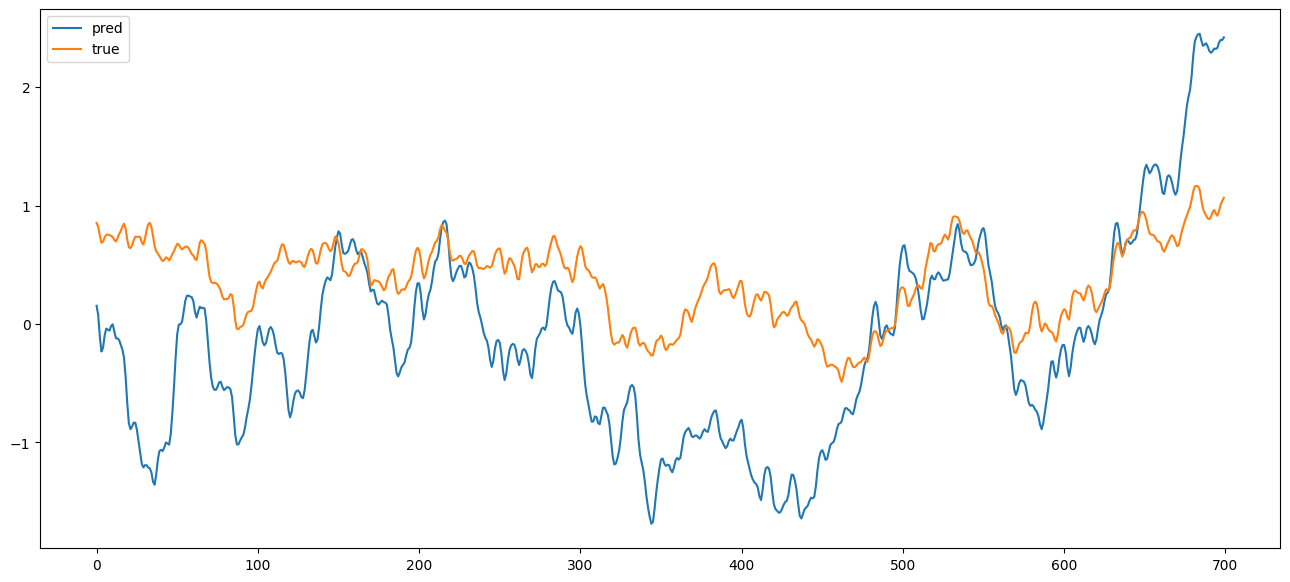

In [7]:
plt.figure(figsize=(16, 7))
plt.plot(pred[9000:9700,pred_index],label='pred')
plt.plot(z_held[9000:9700],label='true')
plt.legend()

In [ ]:
np.corrcoef(pred[:,0],z_held)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

rank[25,50,100,200,500]
lambda [.1,1,5,10,20]
compute the correlation we want to maximize the corner values
stick with one patient and one node to hold ok
use rbf graph

# displaying things backup

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# %pip install ipympl
%matplotlib widget
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d') 
ax.scatter(xyz_clean[:,0],xyz_clean[:,1],xyz_clean[:,2],c=xyz_clean[:,2])
patient = 0
num_seen = 0
for i in range(0,xyz_clean.shape[0]):
    if cleaned[patient].ndim == 2: #this is to avoid the special hold out guy
        if num_seen == cleaned[patient].shape[1]:
            num_seen = -1
            patient +=1
        num_seen+=1
    else:
        patient +=1
    ax.text(xyz_clean[i,0],xyz_clean[i,1],xyz_clean[i,2],s=str(i) + "pat:" + str(patient))

# Comparing the correlation matrixs of held out vs none held out stuff (ignore most of this)

In [ ]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
#xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz,notch_size=.05,minus_mean=True)
xyz_clean, mapping_clean, kept_global_indices, cleaned, file_held, global_held_index = full_preprocessing_hold(ecogs,xyz,notch_size=.05,minus_mean=True,pat_to_hold=0)
print('Preprocessing done')
patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)
print('Got Correlation Matrices, done!')

In [ ]:
xyz_clean_2, mapping_clean_2, kept_global_indices_2, cleaned_2 = full_preprocessing(ecogs,xyz,notch_size=.05,minus_mean=True)
print('Preprocessing done')
patient_corr_mat_2 = make_patient_correlation_matrix(xyz_clean_2,cleaned_2,mapping_clean_2)
print('Got Correlation Matrices, done!') #patient_corr_mat

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(patient_corr_mat[0][0:43]-patient_corr_mat_2[0], cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Difference between held out and not held out matrices')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(patient_corr_mat[9], cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:

temp=xyz_clean[310:410]
fig = plt.figure(figsize=(10, 8))
# The 'projection="3d"' argument is key to creating 3D axes
ax = fig.add_subplot(projection='3d') 
ax.scatter(temp[:,0],temp[:,1],temp[:,2],c=temp[:,2])
for i in range(310,410):
    ax.text(xyz_clean[i,0],xyz_clean[i,1],xyz_clean[i,2],s=str(i),)


In [ ]:
from noah_production_funcs import create_u
U_det, loss = create_u(k=30,r=600,lamb=.0005,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,training_steps=1000)

In [ ]:
(U_det@U_det.T).shape

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap((U_det@U_det.T), cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
def single_patient_prediction_test(patient,num_hold_out,ecogs,correlation_matrix):
    #, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    ######################## this gets everything for this patient ########################
    if torch.is_tensor(correlation_matrix):
        correlation_matrix = correlation_matrix.numpy()
    patient_node_start = 0  #these are where this patients electrodes would start and end in the correlation matrix
    patient_node_end = -1 #!THESE ARE INCLUSIVE VALUES, BOTH OF THEM
    for i,pat in enumerate(ecogs):
        if i < patient:
            patient_node_start += pat.shape[1]
        if i <=patient:
            patient_node_end += pat.shape[1]
    K_patient = correlation_matrix[:,patient_node_start:patient_node_end+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    Kalpha_alpha = K_patient[patient_node_start:patient_node_end+1,:]
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 

    if patient_node_start == 0: #if the patient is the first (and thus all the nonobserved nodes are 'below' the observed ones)
        Kbeta_alpha = K_patient[patient_node_end+1:,:] # get all rows the patient doesnt have observed 
    else:# else the patient is not the first (and thus all the nonobserved nodes are both 'below' and 'above' the observed ones in the correlation matrix)
        Kbeta_alpha_1 = K_patient[0:patient_node_start,:]
        Kbeta_alpha_2 = K_patient[patient_node_end+1:,:]
        Kbeta_alpha = (np.vstack((Kbeta_alpha_1,Kbeta_alpha_2)))
    Y_patient = Y_z_score[:,0:patient_node_end+1]
    Yt = Y_patient.T
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T
    return pred




    patient_elec_count = [] #gets the number of electrodes per patients 
    total_nodes = 0
    
    y_valid = None
    patient_node_end = -1
    for i,pat in enumerate(ecogs):
        patient_elec_count.append(pat.shape[1])
        total_nodes +=pat.shape[1]
        if i < patient:
            patient_node_start += pat.shape[1]
        if i <=patient:
            patient_node_end += pat.shape[1]
    print("np.array(patient_elec_count).sum")
    print(np.array(patient_elec_count).sum())
    particular_patient_count = ecogs[patient].shape[1] #gets num electrodes for this one patient
    print("particular_patient_count")
    print(particular_patient_count)
    
    

    electrodestart = patient_node_start
    electrodeend = patient_node_end-num_hold_out





    if num_hold_out > 0: #we only do this when we want to do some validation
        validationstart = electrodeend+1
        validationend = patient_node_end
        y_valid = Y_z_score[:,particular_patient_count-num_hold_out:]
        print("y_valid.shape")
        print(y_valid.shape)

    

    Y_patient = Y_z_score[:,0:electrodeend+1] #gets all the z_score values from electrodes the patient we did observed  (and arent holding out)  
    print("Y_patient.shape")
    print(Y_patient.shape)



    ########### Building our K's ###########

    K_patient = correlation_matrix[:,electrodestart:electrodeend+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    Kalpha_alpha = K_patient[electrodestart:electrodeend+1,:] #gets all the rows that the patient has observed data for



    print("Kalpha_alpha.shape")
    print(Kalpha_alpha.shape)



#!EVERYTHING ABOVE IS CORRECT I THINK ^^^^^^^^




    if electrodestart == 0: #if the patient is the first (and thus all the nonobserved nodes are 'below' the observed ones)
        Kbeta_alpha = K_patient[electrodeend+1:,:] # get all rows the patient doesnt have observed 
        #####! CORRECT?
    else:# else the patient is not the first (and thus all the nonobserved nodes are both 'below' and 'above' the observed ones in the correlation matrix)
        Kbeta_alpha_1 = K_patient[0:electrodestart,:]
        Kbeta_alpha_2 = K_patient[electrodeend+1:,:]
        Kbeta_alpha = (np.vstack((Kbeta_alpha_1,Kbeta_alpha_2)))
        # Also gets the true Z score values for comparision purposes
    print("Kbeta_alpha.shape")
    print(Kbeta_alpha.shape)
    ########### Using the forumla ###########
    #Y_patient = Y_z_score[:,0:particular_patient_count-num_hold_out] #gets all the z_score values from electrodes the patient we did observed  (and arent holding out)  
    Yt = Y_patient.T #take the transpose of it
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper

    return pred,y_valid

In [ ]:
def single_patient_prediction_pure_test(patient,ecogs,correlation_matrix):
    #, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    ######################## this gets everything for this patient ########################
    if torch.is_tensor(correlation_matrix):
        correlation_matrix = correlation_matrix.numpy()
    patient_node_start = 0  #these are where this patients electrodes would start and end in the correlation matrix
    patient_node_end = -1 #!THESE ARE INCLUSIVE VALUES, BOTH OF THEM
    for i,pat in enumerate(ecogs):
        if i < patient:
            patient_node_start += pat.shape[1]
        if i <=patient:
            patient_node_end += pat.shape[1]
    K_patient = correlation_matrix[:,patient_node_start:patient_node_end+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    Kalpha_alpha = K_patient[patient_node_start:patient_node_end+1,:]
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 

    if patient_node_start == 0: #if the patient is the first (and thus all the nonobserved nodes are 'below' the observed ones)
        Kbeta_alpha = K_patient[patient_node_end+1:,:] # get all rows the patient doesnt have observed 
    else:# else the patient is not the first (and thus all the nonobserved nodes are both 'below' and 'above' the observed ones in the correlation matrix)
        Kbeta_alpha_1 = K_patient[0:patient_node_start,:]
        Kbeta_alpha_2 = K_patient[patient_node_end+1:,:]
        Kbeta_alpha = (np.vstack((Kbeta_alpha_1,Kbeta_alpha_2)))
    Y_patient = Y_z_score[:,0:patient_node_end+1]
    Yt = Y_patient.T
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T
    return pred

# prediction

In [ ]:
#from noah_production_funcs import single_patient_prediction
print(cleaned[1].shape)
pred = single_patient_prediction_pure_test(patient=0,ecogs=cleaned,correlation_matrix=(U_det@U_det.T))


In [ ]:
plt.plot(pred[9000:9500,11],label='pred',alpha=1)

In [ ]:
def single_patient_prediction_hold_test(patient,num_hold_out,ecogs,correlation_matrix):
    #, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    ######################## this gets everything for this patient ########################
    if torch.is_tensor(correlation_matrix):
        correlation_matrix = correlation_matrix.numpy()
    patient_node_start = 0  #these are where this patients electrodes would start and end in the correlation matrix
    patient_node_end = -1 #!THESE ARE INCLUSIVE VALUES, BOTH OF THEM
    patient_total_nodes = Y_z_score.shape[1]
    for i,pat in enumerate(ecogs):
        if i < patient:
            patient_node_start += pat.shape[1]
        if i <=patient:
            patient_node_end += pat.shape[1]
    #? patient_node_start doesnt change with being held out
    #? patient_node_end does thought
    patient_node_end -= num_hold_out

    y_valid = Y_z_score[:,patient_total_nodes-num_hold_out:] 



    K_patient = correlation_matrix[:,patient_node_start:patient_node_end+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    Kalpha_alpha = K_patient[patient_node_start:patient_node_end+1,:]
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 

    if patient_node_start == 0: #if the patient is the first (and thus all the nonobserved nodes are 'below' the observed ones)
        Kbeta_alpha = K_patient[patient_node_end+1:,:] # get all rows the patient doesnt have observed 
    else:# else the patient is not the first (and thus all the nonobserved nodes are both 'below' and 'above' the observed ones in the correlation matrix)
        Kbeta_alpha_1 = K_patient[0:patient_node_start,:]
        Kbeta_alpha_2 = K_patient[patient_node_end+1:,:]
        Kbeta_alpha = (np.vstack((Kbeta_alpha_1,Kbeta_alpha_2)))
    Y_patient = Y_z_score[:,0:patient_total_nodes-num_hold_out+1]
    print("Y_patient.shape")
    print(Y_patient.shape)
    Yt = Y_patient.T
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T
    return pred,y_valid

In [ ]:
pred,y_valid = single_patient_prediction_hold_test(patient=1,num_hold_out=5,ecogs=cleaned,correlation_matrix=(U_det@U_det.T))

In [ ]:
y_valid.shape

In [ ]:
node = 0
plt.plot(pred[9000:9500,0],label='pred',alpha=1)
plt.plot(y_valid[9000:9500,0],alpha=.5) #30
plt.legend()

In [ ]:
plt.plot(loss)

In [ ]:
np.diag(U_det@U_det.T)

In [ ]:
def object_func(C,U,L,lamb,patient_node_num):
    sum = torch.zeros(1,requires_grad=True) 
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes] #all columns of rows iter+num of nodes + 1 
        #print(len(u[:,0]))


        ut = torch.empty((100,len(u)))
        iter = 0
        for row in u:
            ut[:,iter] = row
        ######## Compute u@u.T
        print("ut.shape")
        print(ut.shape)
        print(ut)
        #TODO: 
        #TODO: 
        #TODO: Investage whether you can copy things around and get around the constrain anonying stuff
        #TODO: 
        #TODO: 

        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum


def create_u(k,r,lamb,patient_corr_mat,xyz_clean,object_func):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0] #649
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    # turn indices lists into pairwiase combos
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)
    ############## Preparing function inputs ##############
    Glaplacian = nx.linalg.laplacian_matrix(G).toarray()
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    #r = 200
    #lamb = 1
    patient_node_num = []
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing U and its manifold ##############
    rng = np.random.default_rng()
    sphere = geoopt.manifolds.Sphere()
    U = []
    for i in range(num_nodes): #for each row in the U matrix
        U_intial = rng.uniform(1,2,(1,r)) #random values to start with
        U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U row is normalized
        U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
        U.append(geoopt.ManifoldParameter(U_tensor,manifold=sphere))

    ############## Training U ##############
    optimizer = geoopt.optim.RiemannianAdam(U, lr=0.01)
    loss_list = []
    grads = []
    print("Optimizing U")
    for step in tqdm(range(1000)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb,patient_node_num) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
    return U.detach()

In [ ]:
U_det = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,object_func=object_func)

In [ ]:
print("Norm of a Column:")
print(torch.linalg.norm(U_det[1,:]))
print("Norm of a Row:")
print(torch.linalg.norm(U_det[1]))

In [ ]:
r=100
rng = np.random.default_rng()
U_intial = rng.uniform(1,2,(2,r)) #random values to start with
U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
#print(U_tensor)
U = torch.empty((2,r))    
with torch.no_grad():
    U[0] = geoopt.ManifoldParameter(U_tensor[0],manifold=geoopt.Sphere())
    U[1] = geoopt.ManifoldParameter(U_tensor[1],manifold=geoopt.Sphere())
U.requires_grad = True
U = U + torch.ones((2,r))    
#print(U.grad_fn)


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()